# K-Means

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [54]:
x,y_true = make_blobs(n_samples=500, centers=3, cluster_std=0.40, random_state=42)

In [55]:
df = pd.DataFrame(x, columns=['feature_1', 'feature_2'])

In [56]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [57]:
inertia = []
k_range = range(1, 11)

In [58]:
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(x_scaled)
    inertia.append(kmeans.inertia_)

In [59]:
inertia

[999.9999999999997,
 292.6497210816757,
 5.167423476273202,
 4.3535252915955525,
 3.6840516879086267,
 3.2027991457297986,
 2.8259145394457286,
 2.5453971009931404,
 2.259207010166447,
 2.125100669956916]

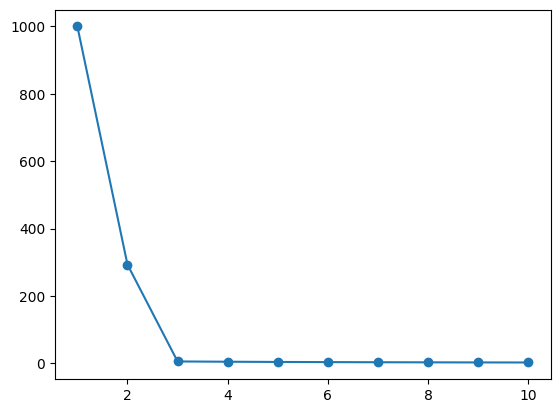

In [60]:
plt.plot(k_range, inertia, marker='o')

In [61]:
kmeans_final = KMeans(n_clusters=3, random_state=42)

In [62]:
cluseter_labels = kmeans_final.fit_predict(x_scaled)

In [63]:
df['cluster'] = cluseter_labels

<Axes: xlabel='feature_1', ylabel='feature_2'>

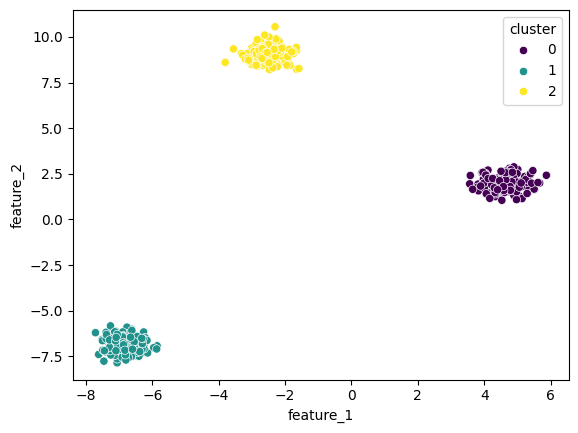

In [64]:
sns.scatterplot(data=df, x='feature_1', y='feature_2', hue='cluster', palette='viridis')

# DBSCAN

In [65]:
from sklearn.datasets import make_moons

In [66]:
x,y_true = make_moons(n_samples=500, noise=0.06, random_state=42)

In [67]:
from sklearn.cluster import KMeans, DBSCAN

In [68]:
df = pd.DataFrame(x, columns=['Feature_1', 'Feature_2'])

In [69]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(df)

In [70]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(x_scaled)

In [71]:
df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

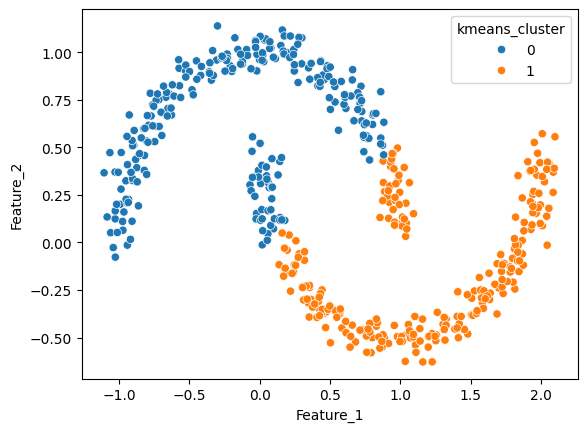

In [72]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')

In [73]:
dbscan = DBSCAN(eps=0.3, min_samples=5)

In [74]:
dbscan_labels = dbscan.fit_predict(x_scaled)

In [75]:
df['dbscan_cluster'] = dbscan_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

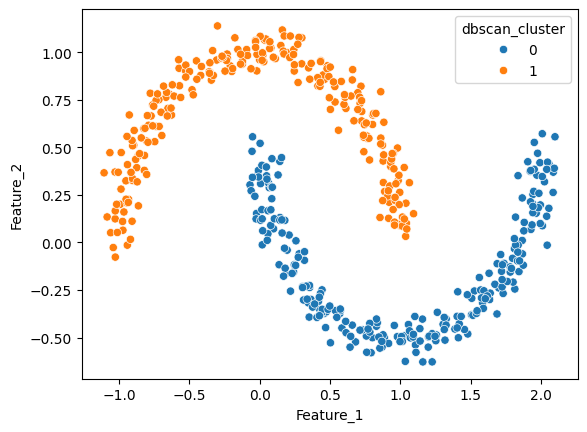

In [76]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')